<a href="https://colab.research.google.com/github/wizm0hit/Gla_ML_Session/blob/main/Gla_ML_Session1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Calculate the avg marks and prin t class fialed or passed is the avg is 50 or above

In [3]:
marks = [45, 60, 72, 38, 90]

total = 0

for i in range(len(marks) - 1):
    total += marks[i]

average = total / len(marks)

if average > 50:
    print("Class passed")
else:
    print("Class failed")

print("Average:", average)

Class failed
Average: 43.0


In [4]:
import pandas as pd

In [5]:
data = {
    "student_id": [101, 102, 103, 104, 105, 106],
    "attendance_percent": [92, 67, 81, 45, 74, 88],
    "assignment_score": [18, 12, 15, 8, 14, 19],
    "quiz_score": [72, 48, 65, 30, 55, 80],
    "lab_completed": [True, False, True, False, True, True]
}

df = pd.DataFrame(data)

df

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed
0,101,92,18,72,True
1,102,67,12,48,False
2,103,81,15,65,True
3,104,45,8,30,False
4,105,74,14,55,True
5,106,88,19,80,True


In [6]:
df.shape

(6, 5)

In [7]:
df.head()

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed
0,101,92,18,72,True
1,102,67,12,48,False
2,103,81,15,65,True
3,104,45,8,30,False
4,105,74,14,55,True


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   student_id          6 non-null      int64
 1   attendance_percent  6 non-null      int64
 2   assignment_score    6 non-null      int64
 3   quiz_score          6 non-null      int64
 4   lab_completed       6 non-null      bool 
dtypes: bool(1), int64(4)
memory usage: 330.0 bytes


In [9]:
df.describe()

,student_id,attendance_percent,assignment_score,quiz_score
count,6.000000,6.000000,6.000000,6.000000
mean,103.500000,74.500000,14.333333,58.333333
std,1.870829,17.073371,4.033196,18.007406
min,101.000000,45.000000,8.000000,30.000000
25%,102.250000,68.750000,12.500000,49.750000
50%,103.500000,77.500000,14.500000,60.000000
75%,104.750000,86.250000,17.250000,70.250000
max,106.000000,92.000000,19.000000,80.000000


In [10]:
df['total_score'] = df['assignment_score'] + df['quiz_score']
df

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed,total_score
0,101,92,18,72,True,90
1,102,67,12,48,False,60
2,103,81,15,65,True,80
3,104,45,8,30,False,38
4,105,74,14,55,True,69
5,106,88,19,80,True,99


In [11]:
df['eligible'] = (
    (df['attendance_percent'] >= 75) &
    (df['total_score'] >= 70) &
    (df['lab_completed'])
)
df

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed,total_score,eligible
0,101,92,18,72,True,90,True
1,102,67,12,48,False,60,False
2,103,81,15,65,True,80,True
3,104,45,8,30,False,38,False
4,105,74,14,55,True,69,False
5,106,88,19,80,True,99,True


In [12]:
eligible_students = df[df["eligible"] == True]
eligible_students

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed,total_score,eligible
0,101,92,18,72,True,90,True
2,103,81,15,65,True,80,True
5,106,88,19,80,True,99,True


# Adding Features

In [13]:
def grade(score):
  if score >= 90:
    return 'A'
  elif score >= 80:
    return 'B'
  elif score >= 70:
    return 'C'
  else:
    return 'F'

df['grade'] = df['total_score'].apply(grade)
df

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed,total_score,eligible,grade
0,101,92,18,72,True,90,True,A
1,102,67,12,48,False,60,False,F
2,103,81,15,65,True,80,True,B
3,104,45,8,30,False,38,False,F
4,105,74,14,55,True,69,False,F
5,106,88,19,80,True,99,True,A


In [14]:
df['at_risk'] = ((df['attendance_percent'] < 75) | (df['total_score'] < 70))
df

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed,total_score,eligible,grade,at_risk
0,101,92,18,72,True,90,True,A,False
1,102,67,12,48,False,60,False,F,True
2,103,81,15,65,True,80,True,B,False
3,104,45,8,30,False,38,False,F,True
4,105,74,14,55,True,69,False,F,True
5,106,88,19,80,True,99,True,A,False


# Visualizations

In [77]:
import matplotlib.pyplot as plt

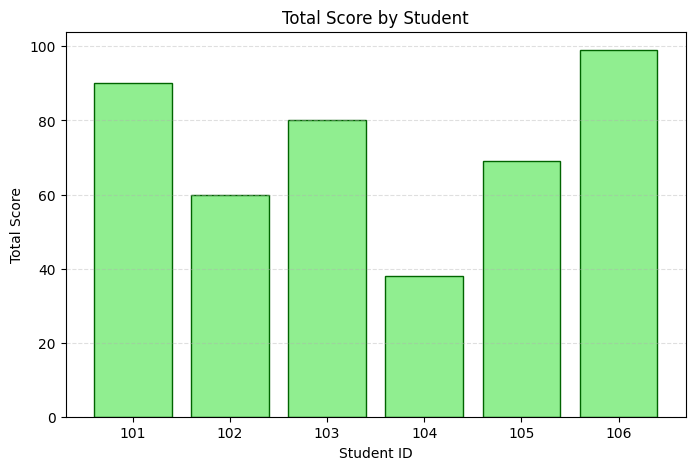

In [78]:
plt.figure(figsize=(8, 5))
plt.bar(
    df['student_id'],
    df['total_score'],
    color = 'lightgreen',
    edgecolor = 'darkgreen'
)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.title('Total Score by Student')
plt.xlabel('Student ID')
plt.ylabel('Total Score')
plt.show()

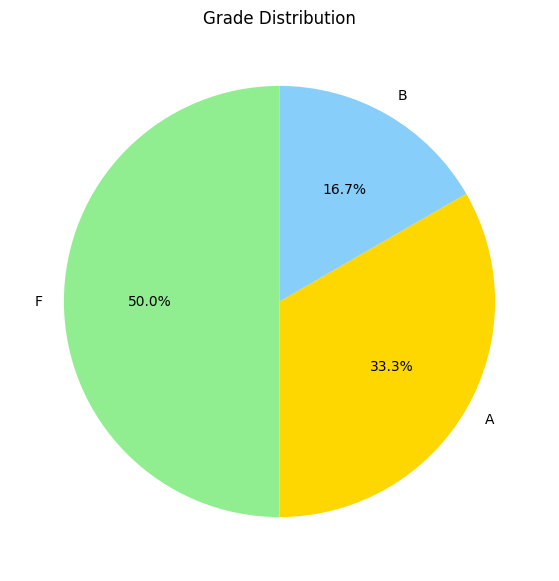

In [91]:
plt.figure(figsize=(12, 7))
grade_counts = df['grade'].value_counts()
plt.pie(
    grade_counts,
    labels = grade_counts.index,
    autopct="%1.1f%%",
    colors=['lightgreen', 'gold', 'lightskyblue'],
    startangle=90
    )

plt.title('Grade Distribution')
plt.show()

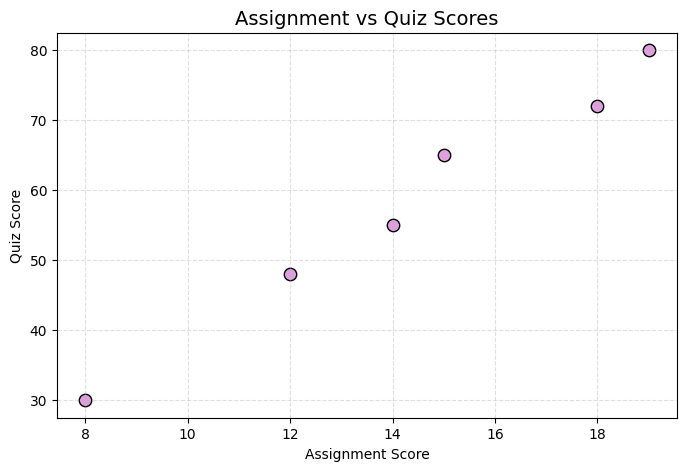

In [87]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df['assignment_score'],
    df['quiz_score'],
    color='plum',
    edgecolors='black',
    s=80
)

plt.title('Assignment vs Quiz Scores', fontsize=14)
plt.xlabel('Assignment Score')
plt.ylabel('Quiz Score')

plt.grid(True, linestyle='--', alpha=0.4)

plt.show()

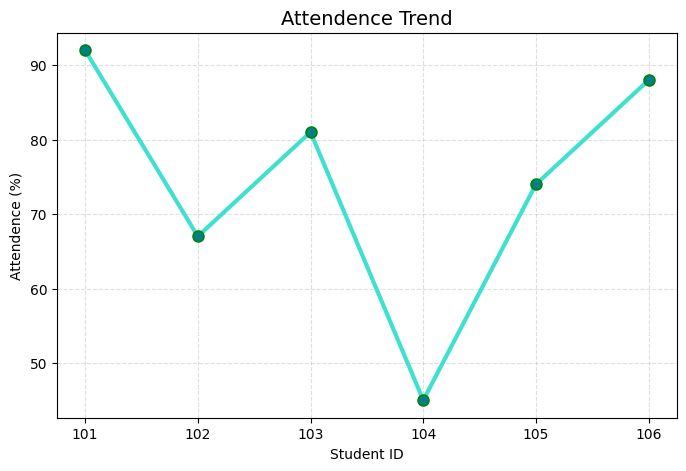

In [86]:
plt.figure(figsize=(8, 5))
plt.plot(
    df['student_id'],
    df['attendance_percent'],
    marker = 'o',
    markersize = 8,
    linewidth = 3,
    color='turquoise',
    markerfacecolor='teal',
    markeredgecolor='green'
)
plt.grid(True, linestyle='--', alpha=0.4)
plt.title('Attendence Trend', fontsize=14)
plt.xlabel('Student ID')
plt.ylabel('Attendence (%)')
plt.show()

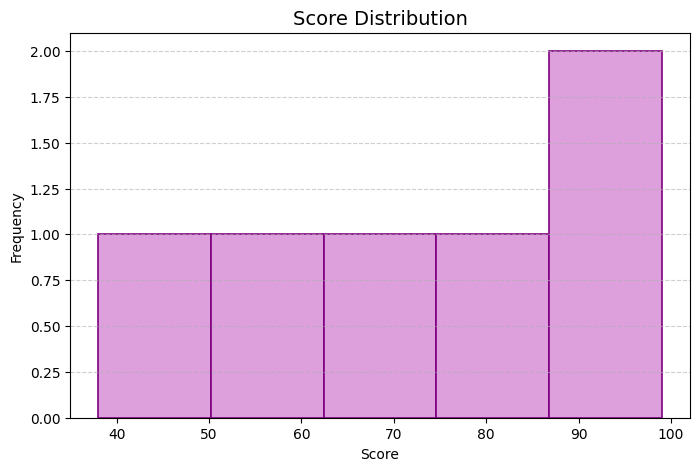

In [85]:
plt.figure(figsize=(8, 5))
plt.hist(
    df['total_score'],
    bins = 5,
    color='plum',
    edgecolor='purple',
    linewidth=1.2
)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.title('Score Distribution', fontsize=14)
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.show()